In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import torch


df = pd.read_csv("../data/AEP_hourly.csv")
df["Datetime"] = pd.to_datetime(df["Datetime"])
df = df.sort_values("Datetime").reset_index(drop=True)
print(df.shape)
print(df.head())
print(df.dtypes)

(121273, 2)
             Datetime   AEP_MW
0 2004-10-01 01:00:00  12379.0
1 2004-10-01 02:00:00  11935.0
2 2004-10-01 03:00:00  11692.0
3 2004-10-01 04:00:00  11597.0
4 2004-10-01 05:00:00  11681.0
Datetime    datetime64[ns]
AEP_MW             float64
dtype: object


In [14]:
print(df.isnull().sum())
print(f"Number of duplicates: {df.duplicated().sum()}")

df = df.drop_duplicates(subset=["Datetime"]) 

print(f"shape after dropping duplicates: {df.shape}")

Datetime    0
AEP_MW      0
dtype: int64
Number of duplicates: 0
shape after dropping duplicates: (121269, 2)


In [15]:
#features
df['hour'] = df['Datetime'].dt.hour
df['day_of_week'] = df['Datetime'].dt.dayofweek
df['month'] = df['Datetime'].dt.month
df['year'] = df['Datetime'].dt.year
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['season'] = df['month'].map({
  12 : 0, 1: 0, 2:0, #winter
  3: 1, 4: 1, 5: 1,    # Spring
    6: 2, 7: 2, 8: 2,    # Summer
    9: 3, 10: 3, 11: 3   # Autumn
})
print(df.head())
print(df.columns.tolist())

             Datetime   AEP_MW  hour  day_of_week  month  year  is_weekend  \
0 2004-10-01 01:00:00  12379.0     1            4     10  2004           0   
1 2004-10-01 02:00:00  11935.0     2            4     10  2004           0   
2 2004-10-01 03:00:00  11692.0     3            4     10  2004           0   
3 2004-10-01 04:00:00  11597.0     4            4     10  2004           0   
4 2004-10-01 05:00:00  11681.0     5            4     10  2004           0   

   season  
0       3  
1       3  
2       3  
3       3  
4       3  
['Datetime', 'AEP_MW', 'hour', 'day_of_week', 'month', 'year', 'is_weekend', 'season']


In [16]:
#normalizing the AEP_MW column(Energy consumption) to a range of 0 to 1 using MinMaxScaler
scaler = MinMaxScaler()
df['AEP_MW_scaled'] = scaler.fit_transform(df[['AEP_MW']])

print(f"original range: {df['AEP_MW'].min()} to {df['AEP_MW'].max()}")
print(f"scaled range: {df['AEP_MW_scaled'].min()} to {df['AEP_MW_scaled'].max()}")

original range: 9581.0 to 25695.0
scaled range: 0.0 to 0.9999999999999999


In [17]:
# creating sliding windows of 24 hours (1 day) to predict the next hour's energy consumption
def create_windows(data, window_size = 24):
  windows = []
  for i in range(len(data) - window_size):
    windows.append(data[i:i+window_size])
  return np.array(windows)

values = df['AEP_MW_scaled'].values
windows = create_windows(values, window_size=24)

print(f"shape of windows: {windows.shape}")


shape of windows: (121245, 24)


In [18]:
# testing 80% and training 20% split of the data
split = int(len(windows) * 0.8)
X_train = windows[:split]
X_test = windows[split:]

print(f"Training windows: {X_train.shape}")
print(f"Test windows: {X_test.shape}")

Training windows: (96996, 24)
Test windows: (24249, 24)


In [19]:
#converting the train and test windows to tensors for use in PyTorch

X_train_tensor = torch.FloatTensor(X_train)
X_test_tensor = torch.FloatTensor(X_test)

print(f"Train tensor shape: {X_train_tensor.shape}")
print(f"Test tensor shape: {X_test_tensor.shape}")

# Save for model notebook
torch.save(X_train_tensor, "../data/X_train.pt")
torch.save(X_test_tensor, "../data/X_test.pt")
torch.save(torch.FloatTensor(scaler.scale_), "../data/scaler_scale.pt")
torch.save(torch.FloatTensor(scaler.min_), "../data/scaler_min.pt")
print("Tensors saved.")

Train tensor shape: torch.Size([96996, 24])
Test tensor shape: torch.Size([24249, 24])
Tensors saved.


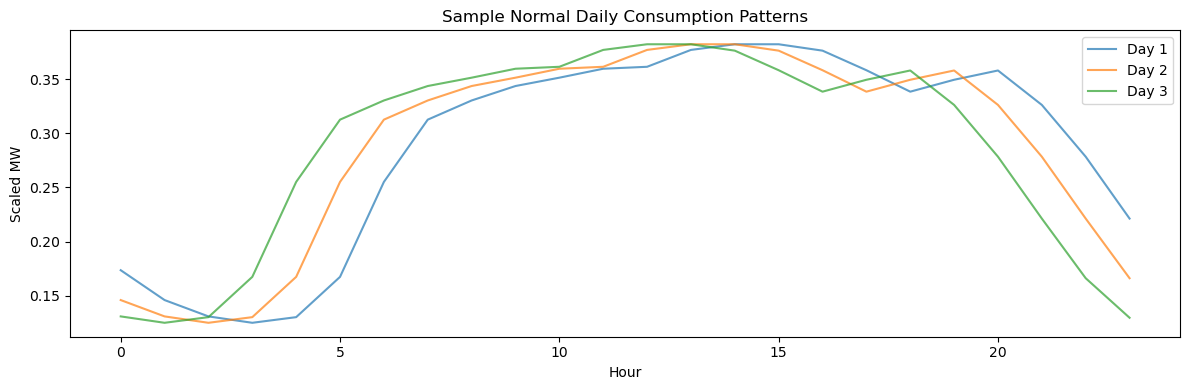

In [20]:
plt.figure(figsize=(12, 4))
for i in range(3):
    plt.plot(X_train[i], alpha=0.7, label=f"Day {i+1}")
plt.title("Sample Normal Daily Consumption Patterns")
plt.xlabel("Hour")
plt.ylabel("Scaled MW")
plt.legend()
plt.tight_layout()
plt.savefig("sample_windows.png")
plt.show()